### Comparative Analysis 
## Rolling Standard Deviation   (Rolling Stdev)
## Short-Time Fourier Transform (STFT)

### Data Preparations

In [31]:
from Comparative_engine.DataLoader import DataLoader
from Comparative_engine.RollingSTDEVEngine import RollingSTDEVEngine
from Comparative_engine.STFTEngine import STFTEngine
from Comparative_engine.ComparatorEngine import ComparatorEngine

import matplotlib.pyplot as plt
import pandas as pd

In [32]:
data_loader = DataLoader()
treated_data = data_loader.load_data()
treated_data

[*********************100%***********************]  1 of 1 completed


Ticker,PSEI.PS,Log Returns
Date,,
2017-01-03,6859.546387,NaN
2017-01-04,7029.142578,0.024423
2017-01-05,7207.586426,0.025069
2017-01-06,7246.336914,0.005362
2017-01-09,7274.469238,0.003875
...,...,...
2019-12-19,7651.972168,-0.010363
2019-12-20,7771.122070,0.015451
2019-12-23,7870.576172,0.012717


# Visualization of raw closings of PSEI (2017-01-03 - 2019-12-27)

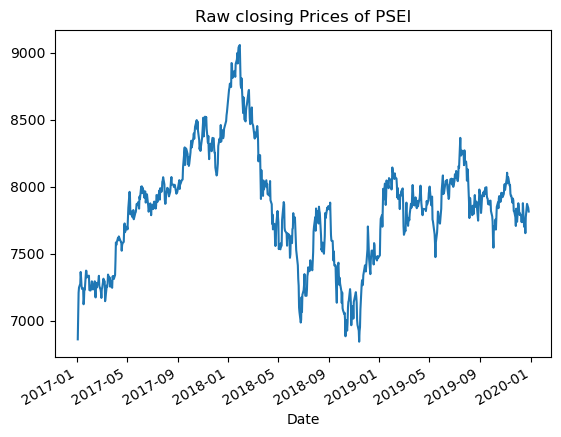

In [33]:
data_loader.visualize_data_raw_returns()

# Visualization of log returns of PSEI (2017-01-03 - 2019-12-27)

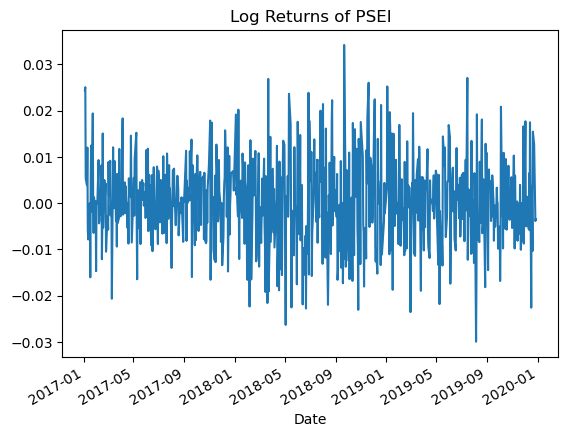

In [34]:
data_loader.visualize_data_log_returns()

### Findings proper
## Visualization preparations

In [35]:
def visualize_data_systems_normalized(
    outcomes : pd.DataFrame
) -> None:
    outcomes["aggregate"][["Rolling_STDEV_Normalized", "STFT_Normalized"]].plot()
    plt.title("Normalized Outputs of Rolling STDEV and STFT")
    plt.xlabel("Time")
    plt.ylabel("Normalized Value")
    plt.legend()
    plt.show()

## 64 days rolling window
- Both systems performed almost the same analytically
- Rolling Standard Deviation has many micromovements due to being more concerned with distance to  mean of the rolling window
- STFT is smoother visually and has successfully reduced short term noise to discern the real closing prices signals

In [36]:
comparator_engine = ComparatorEngine(treated_data)
outcomes = comparator_engine.trial_single_window(interval=64)

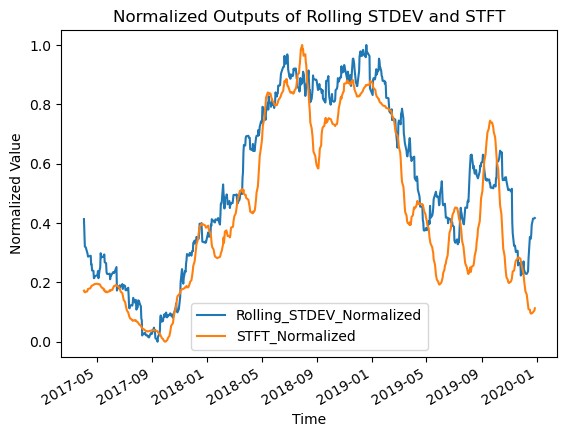

In [37]:
visualize_data_systems_normalized(outcomes)

## 32 day Rolling Window
- Both systems performed almost the same analytically with noted increase on disagreements
- Rolling Standard Deviation has many micromovements due to being more concerned with distance to  mean of the rolling window with the short term movements building up to a general trend in the long term
- STFT is smoother visually and has successfully reduced short term noise to discern the real closing prices signals a increased larger "jumps" are noted

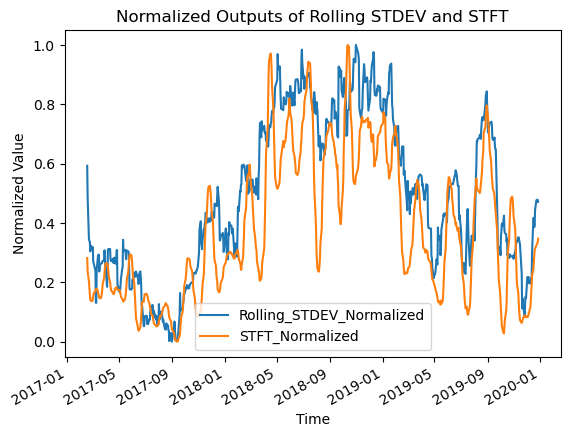

In [38]:
outcomes = comparator_engine.trial_single_window(interval=32)
visualize_data_systems_normalized(outcomes)

## 16 day Rolling Window
- Both systems performed almost the same analytically with more observable disagreements
- Rolling Standard Deviation has more fluctuations big and large that has sharp movements but the buildups on its tips could be noted as a indication that the curren market volatility regime at that time is changing in its momentum
- STFT has a drastic jigsaw movements and has generally been more incomprehensible than rolling standard deviation at such a narrow rolling window

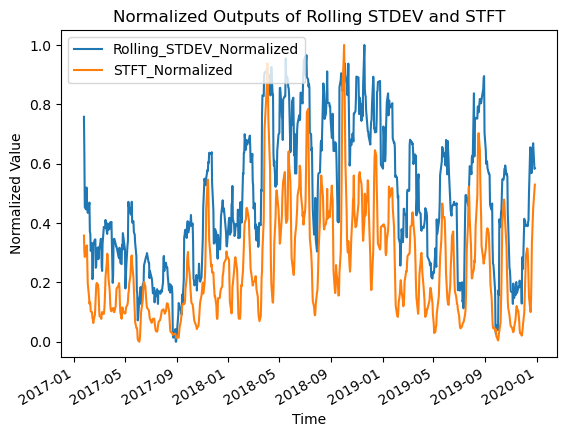

In [39]:
outcomes = comparator_engine.trial_single_window(interval=16)
visualize_data_systems_normalized(outcomes)